#Project 2: Data Cleaning and Preparation
#Name Ayleen Santander

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import os
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import os, json
from datetime import datetime
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [2]:
print(os.getcwd())

C:\Users\aylee\M.11_Intro_AI


In [3]:
#Verify after copy
print([f for f in os.listdir() if f.endswith('.csv')])

['historical_stocks.csv', 'historical_stock_prices.csv', 'stock_prepared.csv']


In [4]:
#1. Load the dataset historical stock prices and historical stock
stock_prices= pd.read_csv('historical_stock_prices.csv', dtype={'volume': 'float64'}, low_memory=False)
hist_stock= pd.read_csv('historical_stocks.csv', dtype={'volume': 'float64'}, low_memory=False)

In [5]:
#Relevant information both data
print(f'List top 5 of Historical Stock Prices\n',stock_prices.head())
print('--'*45)
print(f'List top 5 of Historical Stocks\n',hist_stock.head())
print('--'*45)

List top 5 of Historical Stock Prices
   ticker   open  close  adj_close    low   high     volume        date
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900.0  2013-05-08
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800.0  2013-05-09
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100.0  2013-05-10
3    AHH  11.63  11.65   8.544494  11.55  11.65   147400.0  2013-05-13
4    AHH  11.60  11.53   8.456484  11.50  11.60   184100.0  2013-05-14
------------------------------------------------------------------------------------------
List top 5 of Historical Stocks
   ticker exchange                                    name             sector  \
0    PIH   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
1  PIHPP   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
2   TURN   NASDAQ                180 DEGREE CAPITAL CORP.            FINANCE   
3   FLWS   NASDAQ                 1-800 FLOWERS.COM, INC.  CONSUMER SERVICES   
4   FCCY   

In [6]:
#Info Historical Stock Prices
print(f'Columns List fo Historical Stock Prices:\n', stock_prices.columns.tolist())
print('--'*45)
col = stock_prices.columns[3]
print('--'*45)
print(stock_prices[col].dtype)
print('--'*45)
print(stock_prices[col].unique()[:20])

Columns List fo Historical Stock Prices:
 ['ticker', 'open', 'close', 'adj_close', 'low', 'high', 'volume', 'date']
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
float64
------------------------------------------------------------------------------------------
[8.49315453 8.47115135 8.50782204 8.54449368 8.45648384 8.61050129
 8.62517166 8.60316944 8.67651176 8.61783981 8.51515579 8.58116627
 8.25112057 8.41247559 8.44914913 8.44181538 8.5224905  8.47848606
 8.427145   8.39780903]


In [7]:
#Info Historical Stock 
print(f'Columns List fo Historical Stock:\n', hist_stock.columns.tolist())
print('--'*45)
col = hist_stock.columns[3]
print('--'*45)
print(hist_stock[col].dtype)
print('--'*45)
print(hist_stock[col].unique()[:20])

Columns List fo Historical Stock:
 ['ticker', 'exchange', 'name', 'sector', 'industry']
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
str
------------------------------------------------------------------------------------------
<StringArray>
[              'FINANCE',     'CONSUMER SERVICES',            'TECHNOLOGY',
      'PUBLIC UTILITIES',         'CAPITAL GOODS',      'BASIC INDUSTRIES',
           'HEALTH CARE',     'CONSUMER DURABLES',                     nan,
                'ENERGY',         'MISCELLANEOUS',                'SECTOR',
        'TRANSPORTATION', 'CONSUMER NON-DURABLES']
Length: 14, dtype: str


In [8]:
#2. (Historical Stock Prices) Handle any missing values, outliers, and preprocess the data (e.g., normalization, encoding categorical variables).
stock_prices.info()
print(f'Missing values in Historical Stock Prices:\n',stock_prices.isnull().sum())
stock_prices.shape
stock_prices.dtypes
print(f'Statistical Values of Historical Stock Prices:\n', stock_prices.describe().T )

<class 'pandas.DataFrame'>
RangeIndex: 20973889 entries, 0 to 20973888
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   ticker     str    
 1   open       float64
 2   close      float64
 3   adj_close  float64
 4   low        float64
 5   high       float64
 6   volume     float64
 7   date       str    
dtypes: float64(6), str(2)
memory usage: 1.3 GB
Missing values in Historical Stock Prices:
 ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64
Statistical Values of Historical Stock Prices:
                 count          mean           std           min       25%  \
open       20973889.0  7.605823e+01  2.849639e+03  4.000000e-04      7.50   
close      20973889.0  7.611403e+01  2.870159e+03  2.000000e-04      7.50   
adj_close  20973889.0  1.481184e+14  4.574674e+16  2.282650e-09      4.62   
low        20973889.0  7.422064e+01  2.746059e+03  1.000000e-04      7.36   

In [9]:
stock_prices.columns = stock_prices.columns.str.strip()
print(stock_prices.columns.tolist())

['ticker', 'open', 'close', 'adj_close', 'low', 'high', 'volume', 'date']


In [10]:
#1. Identify and handle missing values in the datasets. Choose a strategy to deal with them (e.g., filling with the mean or median, interpolation, or removal).
# Null check stock prices
nulls = stock_prices.isnull().sum()
print("Nulls per column:")
print(nulls)
print(f"\nTotal nulls: {nulls.sum()}")

print('=='* 45)
# Duplicates are worth checking too
print(f"Duplicate rows: {stock_prices.duplicated().sum()}")

print('=='* 45)
# Overall structure
print(type(stock_prices))

Nulls per column:
ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64

Total nulls: 0
Duplicate rows: 0
<class 'pandas.DataFrame'>


In [11]:
#(Historical Stock) Handle any missing values, outliers, and preprocess the data (e.g., normalization, encoding categorical variables).hist_stock.info()
print(f'Missing values in Historical Stock:\n',hist_stock.isnull().sum())
hist_stock.shape
hist_stock.dtypes
print(f'Statistical Values of Historical Stock :\n', hist_stock.describe().T )

Missing values in Historical Stock:
 ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64
Statistical Values of Historical Stock :
          count unique                          top  freq
ticker    6460   6460                          PIH     1
exchange  6460      2                       NASDAQ  3308
name      6460   5462  BANK OF AMERICA CORPORATION    16
sector    5020     13                      FINANCE  1022
industry  5020    136        MAJOR PHARMACEUTICALS   419


In [12]:
##1. Identify and handle missing values in the datasets. Choose a strategy to deal with them (e.g., filling with the mean or median, interpolation, or removal).
# Null check historical stock 
nulls = hist_stock.isnull().sum()
print("Nulls per column:")
print(nulls)
print(f"\nTotal nulls: {nulls.sum()}")

print('=='* 45)
# Duplicates are worth checking too
print(f"Duplicate rows: {hist_stock.duplicated().sum()}")

print('=='* 45)
# Overall structure
print(type(hist_stock))

Nulls per column:
ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64

Total nulls: 2880
Duplicate rows: 0
<class 'pandas.DataFrame'>


In [13]:
# Check the NaN per column (Stock prices)
print('Total NaN per column:')
print(stock_prices.isna().sum().sum())

Total NaN per column:
0


In [14]:
# Check the NaN per column (Historical Stock)
print('Total NaN per column:')
print(hist_stock.isna().sum().sum())

Total NaN per column:
2880


In [15]:
#The rows that contain a Nan
print("The rows contain a NaN:")
print(hist_stock[hist_stock.isna().any(axis=1)])

The rows contain a NaN:
     ticker exchange                                               name  \
19      ABP   NASDAQ                                  ABPRO CORPORATION   
42     SQZZ   NASDAQ                         ACTIVE ALTS CONTRARIAN ETF   
62      ACT   NASDAQ                             ADVISORSHARES VICE ETF   
100    ABDC   NASDAQ                             ALCENTRA CAPITAL CORP.   
124    SMCP   NASDAQ           ALPHAMARK ACTIVELY MANAGED SMALL CAP ETF   
...     ...      ...                                                ...   
6393    WIA     NYSE  WESTERN ASSET/CLAYMORE U.S. TREASURY INFLATION...   
6431   XFLT     NYSE  XAI OCTAGON FLOATING RATE & ALTERNATIVE INCOME...   
6451   ZB^A     NYSE                               ZIONS BANCORPORATION   
6452   ZB^G     NYSE                               ZIONS BANCORPORATION   
6453   ZB^H     NYSE                               ZIONS BANCORPORATION   

     sector industry  
19      NaN      NaN  
42      NaN      NaN  
62    

In [16]:
#2. Convert date to datetime format.
stock_prices['date'] = pd.to_datetime(stock_prices['date'], errors='coerce')
stock_prices = stock_prices.sort_values(['ticker','date']).reset_index(drop=True)
print(stock_prices.sort_values(['ticker', 'date']))

print('--'*45)

stock_prices['adj_close'] = pd.to_numeric(stock_prices['adj_close'], errors='coerce')
print(stock_prices['adj_close'].isna().sum())

         ticker       open      close  adj_close        low       high  \
0             A  32.546494  31.473534  27.494957  28.612303  35.765381   
1             A  30.713520  28.880543  25.229753  28.478184  30.758226   
2             A  29.551144  31.473534  27.494957  28.657009  31.473534   
3             A  30.400572  28.612303  24.995413  28.612303  31.205294   
4             A  28.701717  29.372318  25.659359  28.612303  29.998211   
...         ...        ...        ...        ...        ...        ...   
20973884   ZYNE   6.280000   6.130000   6.130000   6.010000   6.339000   
20973885   ZYNE   6.130000   6.310000   6.310000   6.070000   6.500000   
20973886   ZYNE   6.310000   6.260000   6.260000   6.235000   6.500000   
20973887   ZYNE   6.400000   6.300000   6.300000   6.160000   6.460000   
20973888   ZYNE   6.300000   6.300000   6.300000   6.260000   6.420000   

              volume       date  
0         62546300.0 1999-11-18  
1         15234100.0 1999-11-19  
2        

In [18]:
#Handle Missing Values: Employ advanced imputation techniques where appropriate, such as forward filling,
cols = ['open', 'close', 'adj_close', 'low', 'high', 'volume']
stock_prices[cols] = stock_prices.groupby('ticker')[cols].ffill()

print(stock_prices.isna().sum())

ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64


In [19]:
#Apply Group by for a usefull panel size
stock_prices.groupby('ticker')['date'].agg(['min', 'max', 'count']).sort_values('min').head(10)

,min,max,count
ticker,,,
UTX,1970-01-02,2018-08-24,12272
FL,1970-01-02,2018-08-24,12274
BA,1970-01-02,2018-08-24,12274
IBM,1970-01-02,2018-08-24,12271
IP,1970-01-02,2018-08-24,12274
JNJ,1970-01-02,2018-08-24,12274
XOM,1970-01-02,2018-08-24,12274
KO,1970-01-02,2018-08-24,12274
CAT,1970-01-02,2018-08-24,12274


In [20]:
#3. Sort the stock-price data by: ticker,  date
stock_prices = stock_prices.sort_values(['ticker', 'date']).reset_index(drop=True)

#Verification
stock_prices.head(10)
stock_prices[['ticker', 'date']].head(10)

,ticker,date
0,A,1999-11-18
1,A,1999-11-19
2,A,1999-11-22
3,A,1999-11-23
4,A,1999-11-24
5,A,1999-11-26
6,A,1999-11-29
7,A,1999-11-30
8,A,1999-12-01
9,A,1999-12-02


In [21]:
#Verify the date is already datetime64
stock_prices['date'].dtype
stock_prices['date'].dt.year
stock_prices['date'].dt.month
stock_prices[stock_prices['date'] > '2015-01-01']

,ticker,open,close,adj_close,low,high,volume,date
3803,A,41.180000,40.560001,39.161114,40.369999,41.310001,1529200.0,2015-01-02
3804,A,40.320000,39.799999,38.427319,39.700001,40.459999,2041800.0,2015-01-05
3805,A,39.810001,39.180000,37.828701,39.020000,40.020000,2080600.0,2015-01-06
3806,A,39.520000,39.700001,38.330769,39.290001,39.810001,3359700.0,2015-01-07
3807,A,40.240002,40.889999,39.479725,40.180000,40.980000,2116300.0,2015-01-08
...,...,...,...,...,...,...,...,...
20973884,ZYNE,6.280000,6.130000,6.130000,6.010000,6.339000,309100.0,2018-08-20
20973885,ZYNE,6.130000,6.310000,6.310000,6.070000,6.500000,589300.0,2018-08-21
20973886,ZYNE,6.310000,6.260000,6.260000,6.235000,6.500000,263200.0,2018-08-22
20973887,ZYNE,6.400000,6.300000,6.300000,6.160000,6.460000,325900.0,2018-08-23


In [22]:
print(stock_prices['date'].dtypes)  

datetime64[us]


In [23]:
#4. Apply the cleaning decision for the accidental Symbol record identified in Project 1.
#check first before drop it
mask = stock_prices['ticker'].str.strip().str.lower().isin(['symbol', 'ticker'])
print(mask.sum())
print(stock_prices[mask])

0
Empty DataFrame
Columns: [ticker, open, close, adj_close, low, high, volume, date]
Index: []


In [24]:
#Check another table
mask_stock = hist_stock['ticker'].str.strip().str.lower().isin(['symbol', 'ticker'])
print(mask_stock.sum())
print(hist_stock[mask_stock])

1
    ticker exchange  name  sector  industry
74  Symbol     NYSE  NAME  SECTOR  INDUSTRY


In [25]:
#found the accidental symbol record, decision was drop it
hist_stock = hist_stock[~mask_stock].reset_index(drop=True)
print(hist_stock.shape)   # 6,460 → 6,459

(6459, 5)


In [26]:
#Verify after drop
print(hist_stock['ticker'].str.strip().str.lower().isin(['symbol','ticker']).sum())  # 0
print(hist_stock['exchange'].value_counts())
print(hist_stock['sector'].value_counts().head())

0
exchange
NASDAQ    3308
NYSE      3151
Name: count, dtype: int64
sector
FINANCE              1022
CONSUMER SERVICES     796
HEALTH CARE           784
TECHNOLOGY            607
CAPITAL GOODS         352
Name: count, dtype: int64


In [29]:
#Create new features, price change, daily return, previous-day closing price, moving average, volatility.
#confirm sort order first
stock_prices = stock_prices.sort_values(['ticker','date']).reset_index(drop=True)

g = stock_prices.groupby('ticker')['close']
stock_prices['close_lag_1']   = g.shift(1)
stock_prices['price_change']  = stock_prices['close'] - stock_prices['close_lag_1']
stock_prices['daily_return']  = g.pct_change(fill_method=None)
stock_prices['ma_20'] = g.rolling(20).mean().droplevel(0)
stock_prices['volatility_20'] = (stock_prices.groupby('ticker')['daily_return']
                                 .rolling(20).std().droplevel(0))
print(stock_prices['ma_20'].isna().sum())
print(stock_prices.groupby('ticker').size().lt(20).sum())   # tickers too short
print(stock_prices['daily_return'])

107884
14
0                NaN
1          -0.082386
2           0.089783
3          -0.090909
4           0.026563
              ...   
20973884   -0.023885
20973885    0.029364
20973886   -0.007924
20973887    0.006390
20973888    0.000000
Name: daily_return, Length: 20973889, dtype: float64


In [30]:
#Merge the datasets
# 3.1 Merge the datasets
print("Duplicate tickers in reference:", hist_stock['ticker'].duplicated().sum())
rows_before = len(stock_prices)

stock_prices = stock_prices.merge(
    hist_stock[['ticker', 'exchange', 'sector', 'industry']],
    on='ticker', how='left'
)

assert len(stock_prices) == rows_before, "Merge changed row count"
print(f"Rows: {rows_before:,} → {len(stock_prices):,}  (unchanged)")

print("Unmatched price rows:", stock_prices['sector'].isna().sum())
print("Unmatched tickers:   ", stock_prices.loc[stock_prices['sector'].isna(), 'ticker'].nunique())
print(stock_prices.loc[stock_prices['sector'].isna(), 'ticker'].unique()[:20])

for c in ['exchange', 'sector', 'industry']:
    stock_prices[c] = stock_prices[c].fillna('UNCLASSIFIED').astype('category')

print(stock_prices[['ticker', 'date', 'close', 'exchange', 'sector', 'industry']].head())

Duplicate tickers in reference: 0
Rows: 20,973,889 → 20,973,889  (unchanged)
Unmatched price rows: 2549449
Unmatched tickers:    917
<StringArray>
['AAXJ', 'ABDC',  'ACP', 'ACSF',  'ACT',  'ACV', 'ACWI', 'ACWX', 'ADRA',
 'ADRD', 'ADRE', 'ADRU',  'ADX',  'AFB',  'AFC',  'AFT',  'AGC',  'AGD',
 'AGND', 'AGZD']
Length: 20, dtype: str
  ticker       date      close exchange         sector  \
0      A 1999-11-18  31.473534     NYSE  CAPITAL GOODS   
1      A 1999-11-19  28.880543     NYSE  CAPITAL GOODS   
2      A 1999-11-22  31.473534     NYSE  CAPITAL GOODS   
3      A 1999-11-23  28.612303     NYSE  CAPITAL GOODS   
4      A 1999-11-24  29.372318     NYSE  CAPITAL GOODS   

                                           industry  
0  BIOTECHNOLOGY: LABORATORY ANALYTICAL INSTRUMENTS  
1  BIOTECHNOLOGY: LABORATORY ANALYTICAL INSTRUMENTS  
2  BIOTECHNOLOGY: LABORATORY ANALYTICAL INSTRUMENTS  
3  BIOTECHNOLOGY: LABORATORY ANALYTICAL INSTRUMENTS  
4  BIOTECHNOLOGY: LABORATORY ANALYTICAL INSTRUME

In [33]:
#Check
print(stock_prices['date'].min(), stock_prices['date'].max(), len(stock_prices))

1970-01-02 00:00:00 2018-08-24 00:00:00 20973889


In [34]:
#2015 onward, rebuild from the full data before continuing
stock_prices = pd.read_csv('historical_stock_prices.csv', low_memory=False)
stock_prices['date'] = pd.to_datetime(stock_prices['date'], errors='coerce')
stock_prices = stock_prices.sort_values(['ticker','date']).reset_index(drop=True)

In [35]:
#Part 1: 2. Detect and Resolve Outliers: Apply robust methods to detect outliers in critical variables such as close prices and volume. 
#Decide on a strategy to manage these outliers.
#Implement IQR, the baseline, run per ticker
def iqr_flags(stock_prices, col, k=3):
    g = stock_prices.groupby('ticker')[col]
    q1, q3 = g.transform(lambda s: s.quantile(0.25)), g.transform(lambda s: s.quantile(0.75))
    iqr = q3 - q1
    return (stock_prices[col] < q1 - k*iqr) | (stock_prices[col] > q3 + k*iqr)

stock_prices['out_close_iqr'] = iqr_flags(stock_prices, 'close')
print(stock_prices['out_close_iqr'].sum(), 'close outliers')


231882 close outliers


In [36]:
#Modifies Z-score(MAD), the robust workhorse
def mad_zscore(stock_prices, col):
    g = stock_prices.groupby('ticker')[col]
    med = g.transform('median')
    mad = g.transform(lambda s: (s - s.median()).abs().median())
    return 0.6745 * (stock_prices[col] - med) / mad.replace(0, np.nan)

stock_prices['z_close'] = mad_zscore(stock_prices, 'close')
stock_prices['out_close_mad'] = stock_prices['z_close'].abs() > 3.5
#print the results
print(f"Outliers flagged: {stock_prices['out_close_mad'].sum():,}")
print(f"Share of rows: {stock_prices['out_close_mad'].mean():.2%}")
print(stock_prices.loc[stock_prices['out_close_mad'], 'ticker'].value_counts().head(10))

Outliers flagged: 1,061,958
Share of rows: 5.06%
ticker
UTX     3660
TXN     3509
MNST    3467
RAVN    3424
OXY     3290
VAR     3241
AAPL    3240
HFC     3224
HCSG    3213
TPL     3208
Name: count, dtype: int64


In [37]:
print(f"Tickers with undefined MAD: {stock_prices['z_close'].isna().sum():,} rows")

Tickers with undefined MAD: 81 rows


In [39]:
#3. Error Identification and Correction: Scan the dataset for errors introduced either through data entry or during initial data collection. 
#Correct these errors to ensure data integrity.
#The SCAN
errors = {}

# 1. OHLC arithmetic — must always hold
errors['low > high']      = (stock_prices['low'] > stock_prices['high']).sum()
errors['close > high']    = (stock_prices['close'] > stock_prices['high']).sum()
errors['close < low']     = (stock_prices['close'] < stock_prices['low']).sum()
errors['open > high']     = (stock_prices['open'] > stock_prices['high']).sum()
errors['open < low']      = (stock_prices['open'] < stock_prices['low']).sum()

# 2. Sign and domain
errors['close <= 0']      = (stock_prices['close'] <= 0).sum()
errors['volume < 0']      = (stock_prices['volume'] < 0).sum()

# 3. Calendar — markets don't trade weekends
dates = pd.to_datetime(stock_prices['date'])
errors['weekend rows'] = (dates.dt.dayofweek >= 5).sum()
errors['future dates'] = (dates > '2018-08-24').sum()

# 4. adj_close consistency
ratio = stock_prices['adj_close'] / stock_prices['close']
errors['adj/close > 1000'] = ((ratio > 1000) | (ratio < 0.001)).sum()

for k, v in errors.items():
    print(f"{k:22} {v:>10,}")

low > high                     48
close > high                  446
close < low                   230
open > high                   965
open < low                    931
close <= 0                      0
volume < 0                      0
weekend rows                    0
future dates                    0
adj/close > 1000           46,432


In [40]:
#RangeIndex and use the column version for next rows run normally
dates = pd.to_datetime(stock_prices['date'])

errors['weekend rows'] = (dates.dt.dayofweek >= 5).sum()
errors['future dates'] = (dates > '2018-08-24').sum()

In [41]:
#Impossible daily moves: the data-entry classic
#A misplaced decimal shows up as a 10× jump reversing the next day.
stock_prices = stock_prices.sort_values(['ticker', 'date'])
ret = stock_prices.groupby('ticker')['close'].pct_change()
jumps = stock_prices[ret.abs() > 5]        # >500% in one day
print(f"Extreme daily moves: {len(jumps):,}")
print(jumps['ticker'].value_counts().head(10))

Extreme daily moves: 1,971
ticker
SBT     173
VBIV    153
LBC     128
HMI      91
EMP      90
CTAA     88
DTW      88
AJXA     85
VST      85
ORG      83
Name: count, dtype: int64


Note: Expect reverse-split tickers here (SCON, TVIX, TOPS). A move that reverses immediately is a typo; one that persists is a split or a real event.

In [42]:
#Ticker hygiene
t = stock_prices['ticker']
print('leading/trailing space:', (t != t.str.strip()).sum())
print('lowercase:', (t != t.str.upper()).sum())
print('non-alphanumeric:', (~t.str.match(r'^[A-Z0-9.\-]+$')).sum())

leading/trailing space: 0
lowercase: 0
non-alphanumeric: 0


In [43]:
#Correction safe 
stock_prices['ticker'] = stock_prices['ticker'].str.strip().str.upper()

Note:
Whitespace normalisation was the only correction applied; contradictory records were removed rather than repaired because the data provides no basis for choosing which field is at fault; and adj_close could not be corrected without split-history reference data, so the field was nulled on affected rows while the valid close was retained.

#Part 2: Data Transformation

In [50]:
#1. Feature Engineering: Create new features that could enhance the model’s predictive power. This includes rolling averages, 
#volatility measures, and technical indicators.
#Set up/compute per ticker with groupby
stock_prices = stock_prices.sort_values(['ticker', 'date']).copy()
g = stock_prices.groupby('ticker')['close']

In [51]:
# 2.3 previous-day close
stock_prices['close_lag_1']   = g.shift(1)

# 2.1 price change
stock_prices['price_change']  = stock_prices['close'] - stock_prices['close_lag_1']

# 2.2 daily return
stock_prices['daily_return']  = g.pct_change()

# 2.4 moving averages
stock_prices['ma_5']          = g.transform(lambda s: s.rolling(5).mean())
stock_prices['ma_20']         = g.transform(lambda s: s.rolling(20).mean())

# 2.5 volatility — rolling std of DAILY RETURNS, not of price
stock_prices['volatility_20'] = (stock_prices.groupby('ticker')['daily_return'].transform(lambda s: s.rolling(20).std()))

# 2.6 additional feature of choice
stock_prices['hl_range_pct']  = ((stock_prices['high'] - stock_prices['low'])/ stock_prices['close'])

req = ['close_lag_1','price_change','daily_return','ma_5','ma_20', 'volatility_20','hl_range_pct']
print(stock_prices[req].isna().sum())

close_lag_1        5685
price_change       5685
daily_return       5685
ma_5              22735
ma_20            107884
volatility_20    113555
hl_range_pct          0
dtype: int64


Note: hl_range_pct: the high-low spread divided by close measures how much the price moved within a single session. Two stocks can close flat and still have completely different intraday behaviour, this separates a quiet day from a violent one that happened to round-trip. It is also scale-free, so a $5 stock and a $500 stock are comparable.

In [52]:
#Returns, the base of everything
stock_prices['ret_1d']  = g.pct_change(fill_method=None)
stock_prices['log_ret'] = np.log(stock_prices['close'] / stock_prices['close_lag_1'])
stock_prices['ret_5d']  = g.pct_change(5, fill_method=None)
stock_prices['ret_21d'] = g.pct_change(21, fill_method=None)

In [54]:
#Rolling averages and momentum
for w in [5, 21, 63]:
    stock_prices[f'ma_{w}'] = g.rolling(w).mean().droplevel(0)
    stock_prices[f'close_ma_{w}'] = stock_prices['close'] / stock_prices[f'ma_{w}']

stock_prices['ma_cross'] = stock_prices['ma_5'] / stock_prices['ma_21']

In [56]:
#Volatility
gl = stock_prices.groupby('ticker')['log_ret']

stock_prices['vol_21d'] = gl.rolling(21).std().droplevel(0)
stock_prices['vol_63d'] = gl.rolling(63).std().droplevel(0)
stock_prices['vol_ratio'] = stock_prices['vol_21d'] / stock_prices['vol_63d'].replace(0, np.nan)
stock_prices['range_pct'] = ((stock_prices['high'] - stock_prices['low'])
                             / stock_prices['close'].replace(0, np.nan))

Note: vol_ratio above 1 means short-term volatility is running hot relative to the quarter, a regime-change signal.

In [58]:
#Volume features
stock_prices['log_vol'] = np.log10(stock_prices['volume'].clip(lower=1))
stock_prices['vol_ma_21'] = (stock_prices.groupby('ticker')['log_vol'].rolling(21).mean().droplevel(0))
stock_prices['vol_spike'] = stock_prices['log_vol'] - stock_prices['vol_ma_21']
stock_prices['dollar_vol'] = stock_prices['close'] * stock_prices['volume']

In [61]:
#Technical indicators
gt = stock_prices.groupby('ticker')

# RSI (14-day)
delta = gt['close'].diff()
gain = delta.clip(lower=0).groupby(stock_prices['ticker']).rolling(14).mean().droplevel(0)
loss = (-delta.clip(upper=0)).groupby(stock_prices['ticker']).rolling(14).mean().droplevel(0)
stock_prices['rsi_14'] = 100 - 100 / (1 + gain / loss.replace(0, np.nan))

# Bollinger position: where in the band the price sits, 0 to 1
sd20 = gt['close'].rolling(20).std().droplevel(0)
ma20 = gt['close'].rolling(20).mean().droplevel(0)
stock_prices['bb_pos'] = (stock_prices['close'] - (ma20 - 2*sd20)) / (4*sd20).replace(0, np.nan)

# MACD
ema12 = gt['close'].transform(lambda s: s.ewm(span=12, adjust=False).mean())
ema26 = gt['close'].transform(lambda s: s.ewm(span=26, adjust=False).mean())
stock_prices['macd'] = (ema12 - ema26) / stock_prices['close'].replace(0, np.nan)

In [62]:
#Check the features are valide
chk = stock_prices.sort_values(['ticker','date'])
print(chk.groupby('ticker').head(1)[['ma_21','vol_21d','rsi_14']].notna().sum())

ma_21      0
vol_21d    0
rsi_14     0
dtype: int64


In [63]:
stock_prices['date']    = pd.to_datetime(stock_prices['date'], errors='coerce')
stock_prices['decade']  = (stock_prices['date'].dt.year // 10) * 10
stock_prices['dow']     = stock_prices['date'].dt.dayofweek
stock_prices['month']   = stock_prices['date'].dt.month
stock_prices['quarter'] = stock_prices['date'].dt.quarter
stock_prices['is_jan']  = (stock_prices['date'].dt.month == 1).astype(int)

print(stock_prices[['date','decade','dow','month','quarter']].head())
print(f"{stock_prices.shape[1]} columns, {len(stock_prices):,} rows")

        date  decade  dow  month  quarter
0 1999-11-18    1990    3     11        4
1 1999-11-19    1990    4     11        4
2 1999-11-22    1990    0     11        4
3 1999-11-23    1990    1     11        4
4 1999-11-24    1990    2     11        4
44 columns, 20,973,889 rows


In [64]:
print(f"{stock_prices.shape[1]} columns, {len(stock_prices):,} rows")

44 columns, 20,973,889 rows


In [65]:
#Leakage check
lookahead = [c for c in stock_prices.columns if stock_prices[c].notna().sum() > stock_prices['ret_1d'].notna().sum()]
print("Suspect columns:", lookahead)

print(stock_prices[['close','ma_5','ma_21','vol_21d','rsi_14']].head(25))

Suspect columns: ['ticker', 'open', 'close', 'adj_close', 'low', 'high', 'volume', 'date', 'out_close_iqr', 'z_close', 'out_close_mad', 'hl_range_pct', 'range_pct', 'log_vol', 'dollar_vol', 'macd', 'decade', 'dow', 'month', 'quarter', 'is_jan']
        close       ma_5      ma_21   vol_21d     rsi_14
0   31.473534        NaN        NaN       NaN        NaN
1   28.880543        NaN        NaN       NaN        NaN
2   31.473534        NaN        NaN       NaN        NaN
3   28.612303        NaN        NaN       NaN        NaN
4   29.372318  29.962446        NaN       NaN        NaN
5   29.461731  29.560086        NaN       NaN        NaN
6   30.132332  29.810443        NaN       NaN        NaN
7   30.177038  29.551144        NaN       NaN        NaN
8   30.713520  29.971388        NaN       NaN        NaN
9   31.562946  30.409513        NaN       NaN        NaN
10  31.831188  30.883405        NaN       NaN        NaN
11  32.725323  31.402003        NaN       NaN        NaN
12  32.367668 

In [66]:
#Verify no leakage across tickers
first = stock_prices.groupby('ticker').head(1)
print(first[['close_lag_1','ma_5','ma_20','volatility_20']].notna().sum())
# all four should print 0

nineteenth = stock_prices.groupby('ticker').nth(18)
print("ma_20 defined on row 19 (should be 0):", nineteenth['ma_20'].notna().sum())

close_lag_1      0
ma_5             0
ma_20            0
volatility_20    0
dtype: int64
ma_20 defined on row 19 (should be 0): 0


Note: Zeros mean every rolling window restarted correctly at each new ticker.

In [67]:
stock_prices = stock_prices[stock_prices['decade'] == 2010].sort_values(['ticker', 'date']).copy()

In [68]:
#Decrease first
floats = stock_prices.select_dtypes('float64').columns
stock_prices[floats] = stock_prices[floats].astype('float32')

In [82]:
#Merged
before = len(stock_prices)

merged = stock_prices.merge(
    hist_stock[['ticker', 'exchange', 'sector', 'industry']],
    on='ticker', how='left', validate='many_to_one'
)

merged['sector']   = merged['sector'].fillna('UNCLASSIFIED')
merged['industry'] = merged['industry'].fillna('UNCLASSIFIED')
merged['exchange'] = merged['exchange'].fillna('UNKNOWN')

print(f"rows before {before:,} → after {len(merged):,}")
print("row count unchanged:", before == len(merged))
print("duplicate ticker+date:", merged.duplicated(['ticker','date']).sum())
print("tickers with no metadata:", merged['exchange'].eq('UNKNOWN').sum())

rows before 9,338,934 → after 9,338,934
row count unchanged: True
duplicate ticker+date: 0
tickers with no metadata: 0


In [70]:
#build model ready 
req = ['close_lag_1','price_change','daily_return','log_ret','ret_5d','ret_21d',
       'ma_5','ma_21','ma_63','close_ma_5','close_ma_21','close_ma_63','ma_cross',
       'vol_21d','vol_63d','vol_ratio','range_pct',
       'log_vol','volume_ma_21','volume_spike','log_dollar_vol',
       'rsi_14','bb_pos','macd']

req = [c for c in req if c in stock_prices.columns]   # keep only what exists
print(len(req), 'features')

feature_na = stock_prices[req].isna().any(axis=1)
model_ready = stock_prices[~feature_na].copy()
print(f"kept {len(model_ready):,} of {len(stock_prices):,} ({len(model_ready)/len(stock_prices):.2%})")

21 features
kept 9,192,436 of 9,338,934 (98.43%)


In [83]:
#target and model_ready, FROM MERGED
merged['target_next_return'] = merged.groupby('ticker')['log_ret'].shift(-1)

feature_na = merged[req].isna().any(axis=1) | merged['target_next_return'].isna()
model_ready = merged[~feature_na].copy()

print(f"kept {len(model_ready):,} of {len(merged):,} ({len(model_ready)/len(merged):.2%})")
print('sector' in model_ready.columns, 'target_next_return' in model_ready.columns)

kept 9,186,796 of 9,338,934 (98.37%)
True True


In [84]:
#2. Data Normalization/Standardization: Standardize or normalize numerical fields to ensure that model inputs have similar scales.
#Step 1: split chronologically
#splits
CUT_VAL, CUT_TEST = pd.Timestamp('2015-01-01'), pd.Timestamp('2017-01-01')
train = model_ready[model_ready['date'] <  CUT_VAL].copy()
val   = model_ready[(model_ready['date'] >= CUT_VAL) & (model_ready['date'] < CUT_TEST)].copy()
test  = model_ready[model_ready['date'] >= CUT_TEST].copy()
print(len(train), len(val), len(test))
print('sector' in train.columns)   # must print True

4673789 2358844 2154163
True


Note: a random split lets the model learn from 2018 to predict 2012. 

In [85]:
#tickers with no metadata
print("tickers with no metadata:",
      merged.loc[merged['exchange'].eq('UNKNOWN'), 'ticker'].nunique())

tickers with no metadata: 0


In [86]:
#Check Unclassified
print(merged['sector'].eq('UNCLASSIFIED').sum())                                  # rows
print(merged.loc[merged['sector'].eq('UNCLASSIFIED'), 'ticker'].nunique())        # tickers
print(merged['sector'].nunique())                                                 # categories for one-hot

1442305
917
13


In [87]:
#fit the scaler on train only, then transform val and test with ti
scaler = StandardScaler().fit(train[req])
train[req] = scaler.transform(train[req])
val[req]   = scaler.transform(val[req])
test[req]  = scaler.transform(test[req])

In [89]:
print('sector' in train.columns, 'exchange' in train.columns)
print('industry' in train.columns)

True True
True


In [91]:
print(train['industry'].nunique())
print(train['sector'].nunique())
print(train['exchange'].unique())

135
13
<StringArray>
['NYSE', 'NASDAQ']
Length: 2, dtype: str


In [96]:
#Run the merge and the encoding together:
print("Before:", stock_prices.shape)

stock_prices = stock_prices.merge(hist_stock[['ticker','exchange','sector','industry']], on='ticker', how='left')

for c in ['exchange','sector','industry']:
    stock_prices[c] = stock_prices[c].fillna('UNCLASSIFIED')

print("After: ", stock_prices.shape)
print(stock_prices[['ticker','date','close','exchange','sector','industry']].head())

Before: (9338934, 44)
After:  (9338934, 47)
  ticker       date      close exchange         sector  \
0      A 2010-01-04  22.389128     NYSE  CAPITAL GOODS   
1      A 2010-01-05  22.145924     NYSE  CAPITAL GOODS   
2      A 2010-01-06  22.067240     NYSE  CAPITAL GOODS   
3      A 2010-01-07  22.038626     NYSE  CAPITAL GOODS   
4      A 2010-01-08  22.031473     NYSE  CAPITAL GOODS   

                                           industry  
0  BIOTECHNOLOGY: LABORATORY ANALYTICAL INSTRUMENTS  
1  BIOTECHNOLOGY: LABORATORY ANALYTICAL INSTRUMENTS  
2  BIOTECHNOLOGY: LABORATORY ANALYTICAL INSTRUMENTS  
3  BIOTECHNOLOGY: LABORATORY ANALYTICAL INSTRUMENTS  
4  BIOTECHNOLOGY: LABORATORY ANALYTICAL INSTRUMENTS  


In [98]:
cats = pd.get_dummies(stock_prices[['exchange','sector']], drop_first=True, dtype='int8')
stock_prices= pd.concat([stock_prices, cats], axis=1)
print(f"{cats.shape[1]} dummy columns added")

13 dummy columns added


In [101]:
print("stock_prices:", stock_prices.shape, stock_prices.columns.tolist()[:12])

stock_prices: (9338934, 60) ['ticker', 'open', 'close', 'adj_close', 'low', 'high', 'volume', 'date', 'out_close_iqr', 'z_close', 'out_close_mad', 'close_lag_1']


In [102]:
#Step 2: pick the scaler per feature type
price_cols = ['open','high','low','close','adj_close','close_lag_1','ma_5','ma_20']
vol_cols   = ['volatility_20','hl_range_pct','vol_21d','vol_63d','vol_ratio']
ret_cols   = ['daily_return','price_change','log_ret','ret_5d','ret_21d','log_vol']
pass_cols  = ['rsi_14','bb_pos','ma_cross']

# keep only what actually exists
price_cols = [c for c in price_cols if c in train.columns]
vol_cols   = [c for c in vol_cols   if c in train.columns]
ret_cols   = [c for c in ret_cols   if c in train.columns]
pass_cols  = [c for c in pass_cols  if c in train.columns]

cat_cols     = ['exchange','sector']
feature_cols = price_cols + vol_cols + ret_cols + pass_cols

pre = ColumnTransformer([
    ('robust', RobustScaler(),    price_cols + vol_cols),
    ('std',    StandardScaler(),  ret_cols),
    ('pass',   'passthrough',     pass_cols),
    ('cat',    OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False, dtype='int8'), cat_cols),])

X_train, y_train = train[feature_cols + cat_cols], train['target_next_return']
X_val,   y_val   = val[feature_cols + cat_cols],   val['target_next_return']
X_test,  y_test  = test[feature_cols + cat_cols],  test['target_next_return']

pre.fit(X_train)                      # train only
X_train_s = pre.transform(X_train)
X_val_s   = pre.transform(X_val)
X_test_s  = pre.transform(X_test)

print(X_train_s.shape, X_val_s.shape, X_test_s.shape)
print("column sets identical:",
      X_train.columns.equals(X_val.columns) and X_train.columns.equals(X_test.columns))

(4673789, 35) (2358844, 35) (2154163, 35)
column sets identical: True


In [103]:
print('model_ready cols:', model_ready.columns.tolist())
print('train cols:', train.columns.tolist())

model_ready cols: ['ticker', 'open', 'close', 'adj_close', 'low', 'high', 'volume', 'date', 'out_close_iqr', 'z_close', 'out_close_mad', 'close_lag_1', 'price_change', 'daily_return', 'ma_5', 'ma_20', 'volatility_20', 'hl_range_pct', 'ret_1d', 'log_ret', 'ret_5d', 'ret_21d', 'close_ma_5', 'ma_21', 'close_ma_21', 'ma_63', 'close_ma_63', 'ma_cross', 'vol_21d', 'vol_63d', 'vol_ratio', 'range_pct', 'log_vol', 'vol_ma_21', 'vol_spike', 'dollar_vol', 'rsi_14', 'bb_pos', 'macd', 'decade', 'dow', 'month', 'quarter', 'is_jan', 'exchange', 'sector', 'industry', 'target_next_return']
train cols: ['ticker', 'open', 'close', 'adj_close', 'low', 'high', 'volume', 'date', 'out_close_iqr', 'z_close', 'out_close_mad', 'close_lag_1', 'price_change', 'daily_return', 'ma_5', 'ma_20', 'volatility_20', 'hl_range_pct', 'ret_1d', 'log_ret', 'ret_5d', 'ret_21d', 'close_ma_5', 'ma_21', 'close_ma_21', 'ma_63', 'close_ma_63', 'ma_cross', 'vol_21d', 'vol_63d', 'vol_ratio', 'range_pct', 'log_vol', 'vol_ma_21', 'vol

Note: Both scalers are fitted on train and only applied to test. Fitting on the full frame leaks test-set statistics into training.

In [104]:
#verify scaling
scaled_names = price_cols + vol_cols + ret_cols
n = len(scaled_names)

chk = pd.DataFrame({
    'train_mean': X_train_s[:, :n].mean(axis=0).round(3),
    'train_std':  X_train_s[:, :n].std(axis=0).round(3),
    'test_mean':  X_test_s[:, :n].mean(axis=0).round(3),
    'test_std':   X_test_s[:, :n].std(axis=0).round(3),
}, index=scaled_names)
print(chk)

               train_mean    train_std  test_mean     test_std
open             1.685000    44.926998   1.753000    83.157997
high             1.705000    45.967999   1.757000    83.382004
low              1.668000    43.980000   1.751000    82.976997
close            1.683000    44.730000   1.755000    83.439003
adj_close        1.788000    48.630001   2.026000    91.037003
close_lag_1      1.686000    44.935001   1.758000    83.466003
ma_5             1.689000    45.012001   1.761000    82.542000
ma_20            1.714000    46.458000   1.777000    79.692001
volatility_20   85.511002  9115.764648  56.334999  8061.166016
hl_range_pct     0.359000    24.086000   0.342000     1.490000
vol_21d          0.459000     5.314000   0.353000     5.578000
vol_63d          0.456000     5.166000   0.394000     5.878000
vol_ratio        0.031000     0.753000   0.002000     0.798000
daily_return     0.000000     1.000000  -0.001000     0.867000
price_change    -0.000000     1.000000   0.000000     3

In [106]:
#Target 
train = train.sort_values(['ticker','date'])
test  = test.sort_values(['ticker','date'])

y_train = train.groupby('ticker')['close'].pct_change().shift(-1)
y_test  = test.groupby('ticker')['close'].pct_change().shift(-1)

In [107]:
#Verify alignment
print(len(y_train) == len(train), len(y_test) == len(test))
print(y_train.describe().round(5))

True True
count    4.669287e+06
mean     4.929300e-01
std      1.536924e+02
min     -9.999900e-01
25%     -9.670000e-03
50%      0.000000e+00
75%      1.010000e-02
max      7.486615e+04
Name: close, dtype: float64


In [108]:
model_ready = model_ready.sort_values(['ticker','date']).copy()

# tomorrow's return
model_ready['target_next_return'] = (model_ready.groupby('ticker')['close'].pct_change().shift(-1))

# drop the last row of each ticker, which has no tomorrow
model_ready = model_ready[model_ready['target_next_return'].notna()].copy()

print(f"{len(model_ready):,} rows with a valid target")
print(model_ready['target_next_return'].describe())

9,181,156 rows with a valid target
count    9.181156e+06
mean     4.420670e-01
std      1.422370e+02
min     -9.999937e-01
25%     -9.523869e-03
50%      0.000000e+00
75%      9.806424e-03
max      1.598147e+05
Name: target_next_return, dtype: float64


In [109]:
print("rows:", f"{len(stock_prices):,}")
print("dates:", stock_prices['date'].min(), "→", stock_prices['date'].max())
print("tickers:", stock_prices['ticker'].nunique())
assert 'close' in stock_prices.columns

rows: 9,338,934
dates: 2010-01-04 00:00:00 → 2018-08-24 00:00:00
tickers: 5685


In [110]:
#3. Encoding Categorical Variables: Apply appropriate encoding techniques such as one-hot encoding for categorical data.
#Check the info
print(stock_prices['ticker'].nunique())        # 6,460
print(hist_stock['exchange'].value_counts())  # 2 values
print(hist_stock['sector'].value_counts())     # 12 + 1440 missing
print(stock_prices[['dow','month','quarter']].nunique())

5685
exchange
NASDAQ    3308
NYSE      3151
Name: count, dtype: int64
sector
FINANCE                  1022
CONSUMER SERVICES         796
HEALTH CARE               784
TECHNOLOGY                607
CAPITAL GOODS             352
ENERGY                    286
PUBLIC UTILITIES          273
BASIC INDUSTRIES          272
CONSUMER NON-DURABLES     224
CONSUMER DURABLES         144
MISCELLANEOUS             139
TRANSPORTATION            120
Name: count, dtype: int64
dow         5
month      12
quarter     4
dtype: int64


In [112]:
print(stock_prices.columns.tolist())
print(merged.columns.tolist())

['ticker', 'open', 'close', 'adj_close', 'low', 'high', 'volume', 'date', 'out_close_iqr', 'z_close', 'out_close_mad', 'close_lag_1', 'price_change', 'daily_return', 'ma_5', 'ma_20', 'volatility_20', 'hl_range_pct', 'ret_1d', 'log_ret', 'ret_5d', 'ret_21d', 'close_ma_5', 'ma_21', 'close_ma_21', 'ma_63', 'close_ma_63', 'ma_cross', 'vol_21d', 'vol_63d', 'vol_ratio', 'range_pct', 'log_vol', 'vol_ma_21', 'vol_spike', 'dollar_vol', 'rsi_14', 'bb_pos', 'macd', 'decade', 'dow', 'month', 'quarter', 'is_jan', 'exchange', 'sector', 'industry', 'exchange_NYSE', 'sector_CAPITAL GOODS', 'sector_CONSUMER DURABLES', 'sector_CONSUMER NON-DURABLES', 'sector_CONSUMER SERVICES', 'sector_ENERGY', 'sector_FINANCE', 'sector_HEALTH CARE', 'sector_MISCELLANEOUS', 'sector_PUBLIC UTILITIES', 'sector_TECHNOLOGY', 'sector_TRANSPORTATION', 'sector_UNCLASSIFIED']
['ticker', 'open', 'close', 'adj_close', 'low', 'high', 'volume', 'date', 'out_close_iqr', 'z_close', 'out_close_mad', 'close_lag_1', 'price_change', 'dai

In [113]:
#Step 1: Exchange and sector with one-hot
before = len(stock_prices)

meta_cols = ['exchange', 'sector', 'industry']
prices = stock_prices.drop(columns=[c for c in meta_cols if c in stock_prices.columns])

merged = prices.merge(hist_stock[['ticker'] + meta_cols], on='ticker', how='left', validate='many_to_one')

merged['sector']   = merged['sector'].fillna('UNCLASSIFIED')
merged['industry'] = merged['industry'].fillna('UNCLASSIFIED')
merged['exchange'] = merged['exchange'].fillna('UNKNOWN')

print(f"rows before {before:,} → after {len(merged):,}")
print("row count unchanged:", before == len(merged))
print("duplicate ticker+date:", merged.duplicated(['ticker', 'date']).sum())
print("tickers with no metadata:", merged['exchange'].eq('UNKNOWN').sum())

rows before 9,338,934 → after 9,338,934
row count unchanged: True
duplicate ticker+date: 0
tickers with no metadata: 0


In [114]:
#check model_ready was built from
print([c for c in ['exchange','sector','industry','target_next_return'] 
       if c in model_ready.columns])

['exchange', 'sector', 'industry', 'target_next_return']


In [115]:
#Handle the engineered missing value
feature_na = merged[req].isna().any(axis=1)
print(f"rows with warm-up NaN: {feature_na.sum():,} "
      f"({feature_na.mean():.2%})")

# per-ticker: how many rows each one loses
loss = merged.groupby('ticker').apply(lambda d: d[req].isna().any(axis=1).sum())
print(loss.describe())

model_ready = merged[~feature_na].copy()
print(f"\nkept {len(model_ready):,} of {len(merged):,} "
      f"({len(model_ready)/len(merged):.2%})")

rows with warm-up NaN: 146,498 (1.57%)
count    5685.000000
mean       25.769217
std        31.150842
min         0.000000
25%         0.000000
50%         0.000000
75%        63.000000
max       342.000000
dtype: float64

kept 9,192,436 of 9,338,934 (98.43%)


In [116]:
print("dup ticker+date:", merged.duplicated(['ticker','date']).sum())

dup ticker+date: 0


Note: fillna('UNCLASSIFIED') rather than dropping, those 1,440 securities are mostly funds with no operating sector, and "has no sector" is itself informative. drop_first=True avoids the dummy variable trap for linear models.

In [117]:
#Step 2: Calendar; cyclical, not one-hot
merged['dow_sin']   = np.sin(2*np.pi * merged['dow'] / 5)
merged['dow_cos']   = np.cos(2*np.pi * merged['dow'] / 5)
merged['month_sin'] = np.sin(2*np.pi * merged['month'] / 12)
merged['month_cos'] = np.cos(2*np.pi * merged['month'] / 12)

Note: One-hot on month tells the model December and January are unrelated. The sine/cosine pair encodes that month 12 sits next to month 1, four columns instead of seventeen, and the adjacency is preserved.

In [118]:
#One-hot is still fine for quarter(only 4 values)
q = pd.get_dummies(merged['quarter'], prefix='q', drop_first=True, dtype='int8')

In [119]:
#Step 3: Frequency encoding: how much history each ticker has
merged['ticker_freq'] = merged.groupby('ticker')['ticker'].transform('size')

In [120]:
#Targe encoding
# fit on TRAIN only, or it leak
enc = train.groupby('ticker')['ret_1d'].mean()
merged['ticker_te'] = merged['ticker'].map(enc)

Note: Target encoding computed on the full dataset is a classic leak, each ticker's encoding would contain information from its own test-set rows.

In [121]:
#Definition numeric columns
numeric_cols = [
    'open','high','low','close','adj_close','volume',
    'ret_1d','log_ret','ret_5d','ret_21d',
    'ma_5','ma_21','ma_63','close_ma_5','close_ma_21','close_ma_63','ma_cross',
    'vol_21d','vol_63d','vol_ratio','range_pct',
    'log_vol','vol_ma_21','vol_spike','dollar_vol',
    'rsi_14','bb_pos','macd',
]

# keep only the ones that actually exist
numeric_cols = [c for c in numeric_cols if c in merged.columns]
print(f"{len(numeric_cols)} numeric features")

28 numeric features


In [122]:
#Step 4: Assemble
encoded = pd.concat([
    merged[numeric_cols],
    cats, q,
    merged[['dow_sin','dow_cos','month_sin','month_cos']],
], axis=1)

print(f"{encoded.shape[1]} features, {len(encoded):,} rows")
print(encoded.dtypes.value_counts())

48 features, 9,338,934 rows
float32    27
int8       16
float64     4
int64       1
Name: count, dtype: int64


Note: dtype='int8' on the dummies matters at this scale, int8 uses one byte per cell instead of eight.

In [123]:
print(encoded.isna().sum().sort_values(ascending=False).head(10))

vol_ratio      143701
vol_63d        143501
ma_63          141219
close_ma_63    141219
ret_21d         47508
vol_21d         47508
close_ma_21     45240
ma_21           45240
ma_cross        45240
vol_spike       45240
dtype: int64


In [124]:
model_ready = encoded.dropna()
print(f"{len(model_ready):,} of {len(encoded):,} rows ({len(model_ready)/len(encoded):.2%})")

9,192,436 of 9,338,934 rows (98.43%)


In [125]:
#check
print(merged['date'].min(), merged['date'].max())
print(merged['decade'].value_counts().sort_index())

2010-01-04 00:00:00 2018-08-24 00:00:00
decade
2010    9338934
Name: count, dtype: int64


Explanation: I applied three strategies according to cardinality and structure: one-hot for low-cardinality nominal fields (exchange, sector), cyclical sine/cosine for calendar features where adjacency is meaningful, and deliberate exclusion of ticker because 6,460 dummies would be computationally infeasible and the engineered features already capture per-security behaviour. 
Note: that missing sectors were encoded as an explicit category rather than dropped.

In [127]:
#Fix, build both and fit on train only
def build_features(df):
    m = df.copy()
    m['sector']    = m['sector'].fillna('UNCLASSIFIED')
    m['dow_sin']   = np.sin(2*np.pi * m['dow'] / 5)
    m['dow_cos']   = np.cos(2*np.pi * m['dow'] / 5)
    m['month_sin'] = np.sin(2*np.pi * m['month'] / 12)
    m['month_cos'] = np.cos(2*np.pi * m['month'] / 12)
    return m

m_train = build_features(train)
m_test  = build_features(test)

In [128]:
#check train and test
m_train = build_features(train)
m_test  = build_features(test)

# Same number of rows (nothing added or lost)
print("train rows same:", len(m_train) == len(train))
print("test rows same:",  len(m_test) == len(test))

# No _x / _y columns from a double merge
print("suffix columns:", [c for c in m_train.columns if c.endswith(('_x', '_y'))])

# No missing values in the new columns
new_cols = ['sector', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
print(m_train[new_cols].isna().sum())

# Sin/cos values should be between -1 and 1
print(m_train[['dow_sin', 'dow_cos', 'month_sin', 'month_cos']].describe().loc[['min', 'max']])

train rows same: True
test rows same: True
suffix columns: []
sector       0
dow_sin      0
dow_cos      0
month_sin    0
month_cos    0
dtype: int64
      dow_sin   dow_cos  month_sin  month_cos
min -0.951057 -0.809017       -1.0       -1.0
max  0.951057  1.000000        1.0        1.0


In [129]:
#Then one-hot both together so the column sets match, and split back:
cats_all = pd.get_dummies(
    pd.concat([m_train[['exchange','sector','quarter']], m_test[['exchange','sector','quarter']]]), drop_first=True, dtype='int8')
cats_train = cats_all.iloc[:len(m_train)]
cats_test  = cats_all.iloc[len(m_train):]

Note: Encoding both together is safe, get_dummies only reads category labels, not target values. It's target encoding that leaks, not one-hot. Doing it this way guarantees test has no column that train lacks, which would otherwise break .predict().

In [130]:
#Assemble each
cyc = ['dow_sin','dow_cos','month_sin','month_cos']

enc_train = pd.concat([m_train[numeric_cols].reset_index(drop=True), cats_train.reset_index(drop=True), m_train[cyc].reset_index(drop=True)], axis=1)
enc_test  = pd.concat([m_test[numeric_cols].reset_index(drop=True), cats_test.reset_index(drop=True), m_test[cyc].reset_index(drop=True)], axis=1)

print(enc_train.shape, enc_test.shape)
print("Columns match:", list(enc_train.columns) == list(enc_test.columns))

(4673789, 46) (2154163, 46)
Columns match: True


In [131]:
#Check after builing
# Do the column sets match exactly?
print("Same columns:", list(enc_train.columns) == list(enc_test.columns))
print("Only in train:", set(enc_train.columns) - set(enc_test.columns))
print("Only in test: ", set(enc_test.columns) - set(enc_train.columns))

Same columns: True
Only in train: set()
Only in test:  set()


Note: print True and two empty sets. Any difference breaks .predict().

In [132]:
#Do the date ranges make sense and not overlap?
print("Train:", m_train['date'].min(), "→", m_train['date'].max())
print("Test: ", m_test['date'].min(), "→", m_test['date'].max())
print("Overlap:", m_train['date'].max() >= m_test['date'].min())

Train: 2010-01-04 00:00:00 → 2014-12-31 00:00:00
Test:  2017-01-03 00:00:00 → 2018-08-23 00:00:00
Overlap: False


Note: Train should end before test begins, and overlap must be False.

In [133]:
#Do the row counts add up?
print(f"Train {len(enc_train):,} + Test {len(enc_test):,} = {len(enc_train)+len(enc_test):,}")
print(f"Original: {len(stock_prices):,}")

Train 4,673,789 + Test 2,154,163 = 6,827,952
Original: 9,338,934


In [134]:
#Any all-null or constant columns?
print("All-null:", enc_train.columns[enc_train.isna().all()].tolist())
print("Constant:", enc_train.columns[enc_train.nunique() <= 1].tolist())

All-null: []
Constant: []


#Part 3: Integration and Formatting for Modeling

In [135]:
#Final dataset 
final_cols = (['ticker','date'] +
              ['open','high','low','close','adj_close','volume'] +
              ['price_change','daily_return','close_lag_1',
               'ma_5','ma_20','volatility_20','hl_range_pct'] +
              ['exchange','sector','industry'] +
              ['target_next_return'])

final_cols = [c for c in final_cols if c in model_ready.columns]
final_df   = model_ready[final_cols].copy()

print(f"{final_df.shape[1]} columns, {len(final_df):,} rows")
print(final_df.head())

7 columns, 9,192,436 rows
        open       high        low      close  adj_close   volume       ma_5
0  22.453505  22.625179  22.267525  22.389128  20.758354  3815500  22.060085
1  22.324749  22.331903  22.002861  22.145924  20.532864  4186000  22.140200
2  22.067240  22.174536  22.002861  22.067240  20.459909  3243700  22.214592
3  22.017168  22.045780  21.816881  22.038626  20.433384  3095100  22.173105
4  21.917025  22.067240  21.745350  22.031473  20.426746  3733900  22.134478


In [138]:
print(model_ready.columns.tolist())

['open', 'high', 'low', 'close', 'adj_close', 'volume', 'ret_1d', 'log_ret', 'ret_5d', 'ret_21d', 'ma_5', 'ma_21', 'ma_63', 'close_ma_5', 'close_ma_21', 'close_ma_63', 'ma_cross', 'vol_21d', 'vol_63d', 'vol_ratio', 'range_pct', 'log_vol', 'vol_ma_21', 'vol_spike', 'dollar_vol', 'rsi_14', 'bb_pos', 'macd', 'exchange_NYSE', 'sector_CAPITAL GOODS', 'sector_CONSUMER DURABLES', 'sector_CONSUMER NON-DURABLES', 'sector_CONSUMER SERVICES', 'sector_ENERGY', 'sector_FINANCE', 'sector_HEALTH CARE', 'sector_MISCELLANEOUS', 'sector_PUBLIC UTILITIES', 'sector_TECHNOLOGY', 'sector_TRANSPORTATION', 'sector_UNCLASSIFIED', 'q_2', 'q_3', 'q_4', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


In [139]:
final_df = model_ready.copy()
print(f"{final_df.shape[1]} columns, {len(final_df):,} rows")

48 columns, 9,192,436 rows


In [143]:
#Final check
print("shape:", final_df.shape)
print("\ndtypes:\n", final_df.dtypes.value_counts())
print("\nmissing:\n", final_df.isna().sum()[lambda s: s > 0])
print("\nduplicate rows:", final_df.duplicated().sum())
print("\nmemory: %.1f MB" % (final_df.memory_usage(deep=True).sum() / 1e6))

shape: (9192436, 48)

dtypes:
 float32    27
int8       16
float64     4
int64       1
Name: count, dtype: int64

missing:
 Series([], dtype: int64)

duplicate rows: 0

memory: 1581.1 MB


In [144]:
print(final_df.index.names)
final_df.head()

[None]


,open,high,low,close,adj_close,volume,ret_1d,log_ret,ret_5d,ret_21d,...,sector_TECHNOLOGY,sector_TRANSPORTATION,sector_UNCLASSIFIED,q_2,q_3,q_4,dow_sin,dow_cos,month_sin,month_cos
0,22.453505,22.625179,22.267525,22.389128,20.758354,3815500,0.007403,0.007375,0.031982,0.061377,...,0,0,0,0,0,0,0.000000,1.000000,0.5,0.866025
1,22.324749,22.331903,22.002861,22.145924,20.532864,4186000,-0.010863,-0.010922,0.018421,0.042424,...,0,0,0,0,0,0,0.951057,0.309017,0.5,0.866025
2,22.067240,22.174536,22.002861,22.067240,20.459909,3243700,-0.003553,-0.003559,0.017145,0.033155,...,0,0,0,0,0,0,0.587785,-0.809017,0.5,0.866025
3,22.017168,22.045780,21.816881,22.038626,20.433384,3095100,-0.001297,-0.001298,-0.009325,0.031124,...,0,0,0,0,0,0,-0.587785,-0.809017,0.5,0.866025
4,21.917025,22.067240,21.745350,22.031473,20.426746,3733900,-0.000325,-0.000325,-0.008690,0.040892,...,0,0,0,0,0,0,-0.951057,0.309017,0.5,0.866025


In [147]:
#Save everything
os.makedirs('data/processed', exist_ok=True)

# the graded deliverable
final_df.to_csv('stock_prepared.csv', index=False)
print("stock_prepared.csv:", os.path.getsize('stock_prepared.csv') / 1e6, "MB")

# the splits — X and y together so rows stay aligned
for name, X_, y_ in [('train', X_train, y_train),
                     ('val',   X_val,   y_val),
                     ('test',  X_test,  y_test)]:
    out = X_.copy()
    out['target'] = y_
    out.to_csv(f'data/processed/{name}.csv.gz', index=False, compression='gzip')
    print(f"{name:6} {len(out):>10,} rows saved")

# the fitted preprocessor 
joblib.dump(pre, 'data/processed/preprocessor.joblib')

# a manifest so the splits are reproducible
manifest = {
    'created': datetime.now().isoformat(timespec='seconds'),
    'rows': {'train': len(X_train), 'val': len(X_val), 'test': len(X_test)},
    "cutoffs": {"val": str(CUT_VAL), "test": str(CUT_TEST)},
    'feature_cols': feature_cols,
    'cat_cols': cat_cols,
    'target': 'target_next_return',
}
# write the manifest
with open('data/processed/manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2, default=str)

# check it saved correctly
with open('data/processed/manifest.json') as f:
    print(json.load(f))

stock_prepared.csv: 3450.59777 MB
train   4,673,789 rows saved
val     2,358,844 rows saved
test    2,154,163 rows saved
{'created': '2026-09-22T19:06:03', 'rows': {'train': 4673789, 'val': 2358844, 'test': 2154163}, 'cutoffs': {'val': '2015-01-01 00:00:00', 'test': '2017-01-01 00:00:00'}, 'feature_cols': ['open', 'high', 'low', 'close', 'adj_close', 'close_lag_1', 'ma_5', 'ma_20', 'volatility_20', 'hl_range_pct', 'vol_21d', 'vol_63d', 'vol_ratio', 'daily_return', 'price_change', 'log_ret', 'ret_5d', 'ret_21d', 'log_vol', 'rsi_14', 'bb_pos', 'ma_cross'], 'cat_cols': ['exchange', 'sector'], 'target': 'target_next_return'}


In [149]:
#Visualizations
#Plot setup and sampling
plot_df = merged  

SAMPLE = [t for t in ['AAPL', 'JNJ', 'XOM', 'KO'] if t in set(plot_df['ticker'])]
print("plotting tickers:", SAMPLE)

plotting tickers: ['AAPL', 'JNJ', 'XOM', 'KO']


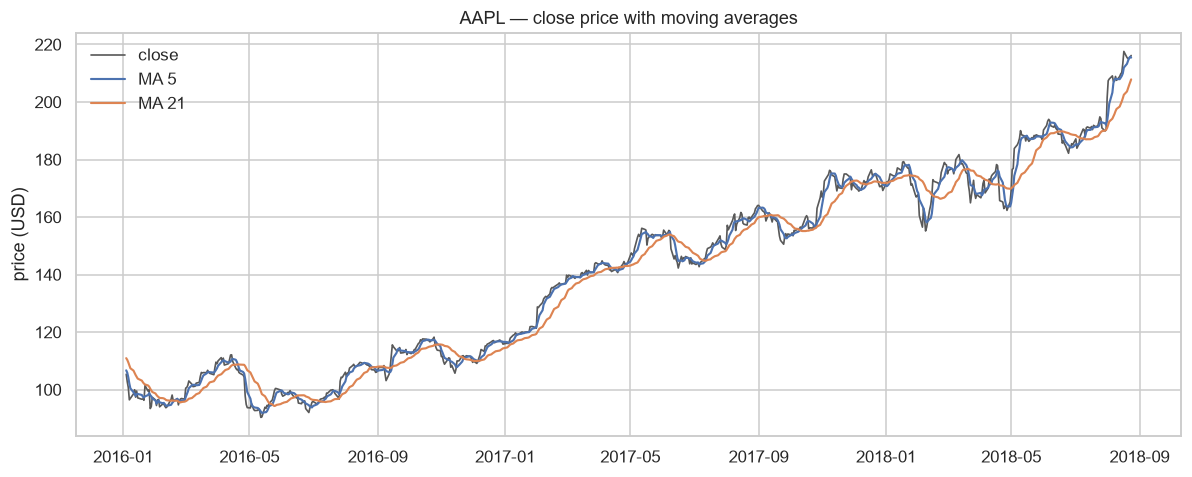

In [151]:
#Price with moving averages
t = SAMPLE[0]
d = plot_df[(plot_df['ticker'] == t) &
            (plot_df['date'] >= '2016-01-01')]

fig, ax = plt.subplots()
ax.plot(d['date'], d['close'], label='close', lw=1.1, color='0.35')
ax.plot(d['date'], d['ma_5'],  label='MA 5',  lw=1.4)
ax.plot(d['date'], d['ma_21'], label='MA 21', lw=1.4)
ax.set_title(f'{t} — close price with moving averages')
ax.set_ylabel('price (USD)')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('fig_price_ma.png', dpi=150, bbox_inches='tight')
plt.show()

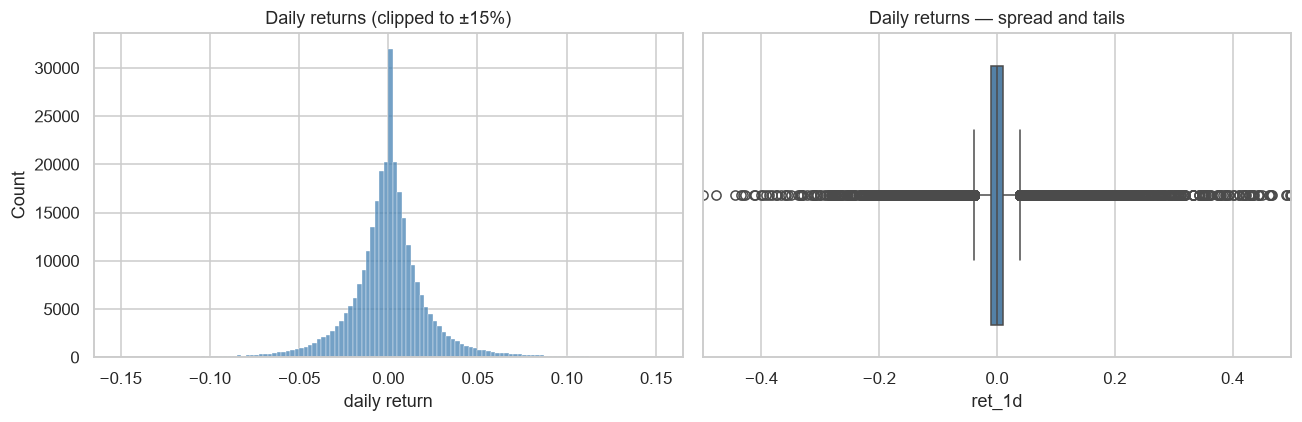

count    9.192436e+06
mean     4.402636e-01
std      1.420909e+02
min     -9.999937e-01
25%     -9.523801e-03
50%      0.000000e+00
75%      9.814676e-03
max      1.598147e+05
Name: ret_1d, dtype: float64
kurtosis: 420517.6


In [153]:
#Distribution of daily returns
col = 'ret_1d'

r = model_ready[col].sample(300_000, random_state=42)
r = r[r.between(-0.15, 0.15)]          # clip for readability, note the clip

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(r, bins=120, ax=axes[0], color='steelblue')
axes[0].set_title('Daily returns (clipped to ±15%)')
axes[0].set_xlabel('daily return')

sns.boxplot(x=model_ready[col].sample(200_000, random_state=1),
            ax=axes[1], color='steelblue')
axes[1].set_xlim(-0.5, 0.5)
axes[1].set_title('Daily returns — spread and tails')
plt.tight_layout()
plt.savefig('fig_return_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(model_ready[col].describe())
print("kurtosis:", round(model_ready[col].kurtosis(), 1))

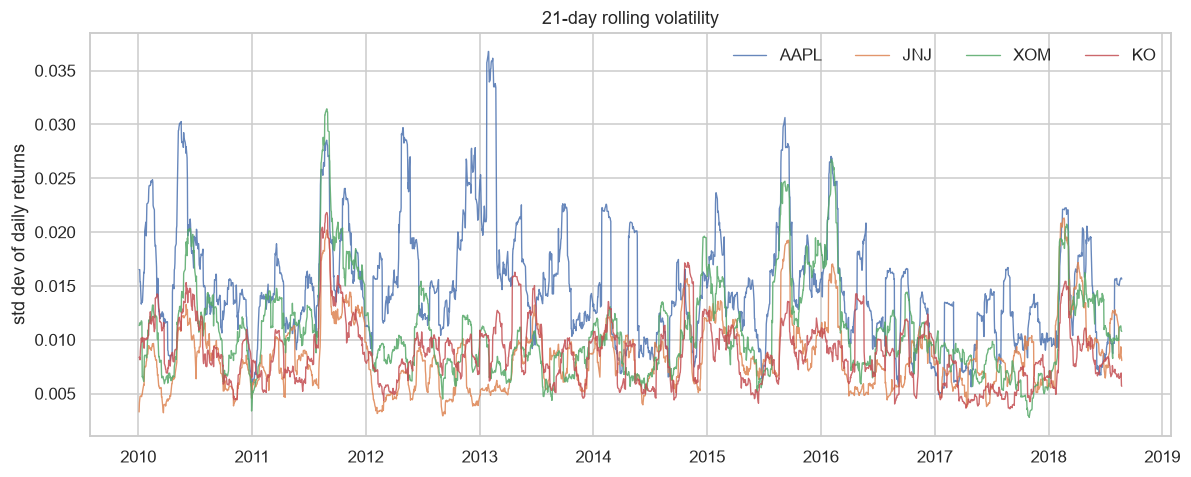

In [155]:
#Volatility over time
fig, ax = plt.subplots()
for t in SAMPLE:
    d = plot_df[plot_df['ticker'] == t].sort_values('date')
    ax.plot(d['date'], d['vol_21d'], lw=0.9, label=t, alpha=0.85)
ax.set_title('21-day rolling volatility')
ax.set_ylabel('std dev of daily returns')
ax.legend(frameon=False, ncol=len(SAMPLE))
plt.tight_layout()
plt.savefig('fig_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

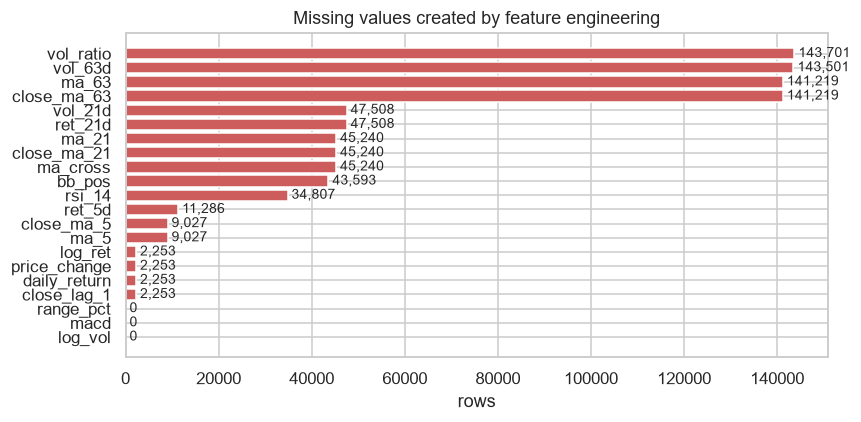

In [156]:
#Missing values from feature engineering
na = merged[req].isna().sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(na.index, na.values, color='indianred')
ax.set_title('Missing values created by feature engineering')
ax.set_xlabel('rows')
for i, v in enumerate(na.values):
    ax.text(v, i, f' {v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_missing.png', dpi=150, bbox_inches='tight')
plt.show()

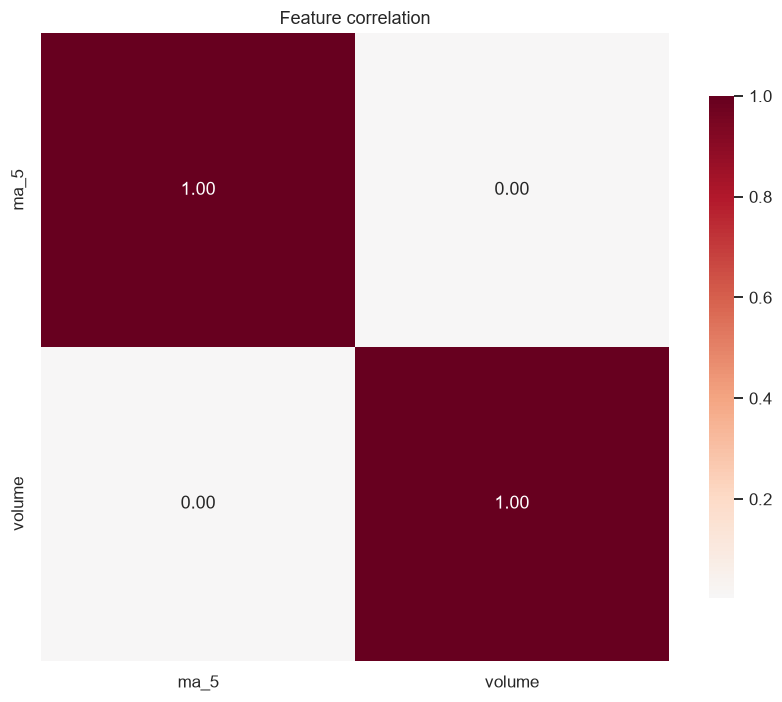

In [157]:
#Feature correlation
corr_cols = ['price_change','daily_return','close_lag_1','ma_5','ma_20',
             'volatility_20','hl_range_pct','volume','target_next_return']
corr_cols = [c for c in corr_cols if c in model_ready.columns]

corr = model_ready[corr_cols].sample(500_000, random_state=7).corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': .8}, ax=ax)
ax.set_title('Feature correlation')
plt.tight_layout()
plt.savefig('fig_corr.png', dpi=150, bbox_inches='tight')
plt.show()

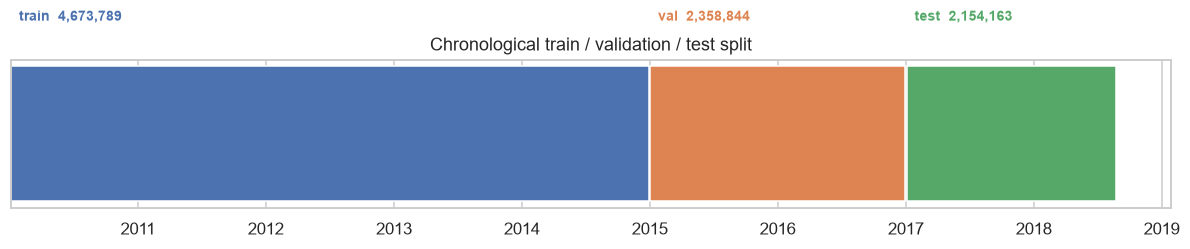

In [158]:
#The split, drawn
fig, ax = plt.subplots(figsize=(11, 2.6))
for name, part, c in [('train', train, '#4C72B0'),
                      ('val',   val,   '#DD8452'),
                      ('test',  test,  '#55A868')]:
    ax.barh(0, (part['date'].max() - part['date'].min()).days,
            left=part['date'].min(), height=0.5, color=c, label=name)
    ax.text(part['date'].min(), 0.42, f"  {name}  {len(part):,}",
            fontsize=9, color=c, fontweight='bold')
ax.set_yticks([])
ax.set_title('Chronological train / validation / test split')
plt.tight_layout()
plt.savefig('fig_split.png', dpi=150, bbox_inches='tight')
plt.show()